In [1]:
import pandas as pd
import numpy as np
import keras
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
dataset_df = pd.read_csv('../dataset/open-meteo_newDataset.csv')

In [3]:
dataset_df.head()

,time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),rain (mm),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),et0_fao_evapotranspiration (mm),vapour_pressure_deficit (kPa),shortwave_radiation_instant (W/m²),direct_radiation_instant (W/m²),diffuse_radiation_instant (W/m²),direct_normal_irradiance_instant (W/m²),terrestrial_radiation_instant (W/m²)
0,2019-01-23T00:00,10.1,84,7.4,8.2,0.0,5,4,2,0,0.0,0.20,0.0,0.0,0.0,0.0,0.0
1,2019-01-23T01:00,9.7,84,7.2,7.7,0.0,4,4,1,0,0.0,0.19,0.0,0.0,0.0,0.0,0.0
2,2019-01-23T02:00,9.6,84,7.0,7.5,0.0,10,10,2,0,0.0,0.19,0.0,0.0,0.0,0.0,0.0
3,2019-01-23T03:00,9.6,84,7.0,7.5,0.0,29,29,4,0,0.0,0.19,0.0,0.0,0.0,0.0,0.0
4,2019-01-23T04:00,10.3,81,7.1,8.4,0.0,35,34,6,0,0.0,0.24,0.0,0.0,0.0,0.0,0.0


In [4]:
dataset_df.columns

Index(['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'dew_point_2m (°C)', 'apparent_temperature (°C)', 'rain (mm)',
       'cloud_cover (%)', 'cloud_cover_low (%)', 'cloud_cover_mid (%)',
       'cloud_cover_high (%)', 'et0_fao_evapotranspiration (mm)',
       'vapour_pressure_deficit (kPa)', 'shortwave_radiation_instant (W/m²)',
       'direct_radiation_instant (W/m²)', 'diffuse_radiation_instant (W/m²)',
       'direct_normal_irradiance_instant (W/m²)',
       'terrestrial_radiation_instant (W/m²)'],
      dtype='object')

In [5]:
dataset_df['time'] = pd.to_datetime(dataset_df['time'])
dataset_df['month'] = dataset_df['time'].dt.month

# Pisahkan data berdasarkan bulan
january_df = dataset_df[dataset_df['month'] == 1]
february_df = dataset_df[dataset_df['month'] == 2]
march_df = dataset_df[dataset_df['month'] == 3]
april_df = dataset_df[dataset_df['month'] == 4]
may_df = dataset_df[dataset_df['month'] == 5]
june_df = dataset_df[dataset_df['month'] == 6]
july_df = dataset_df[dataset_df['month'] == 7]
august_df = dataset_df[dataset_df['month'] == 8]
september_df = dataset_df[dataset_df['month'] == 9]
october_df = dataset_df[dataset_df['month'] == 10]
november_df = dataset_df[dataset_df['month'] == 11]
december_df = dataset_df[dataset_df['month'] == 12]

In [6]:
january_df.set_index('time', inplace=True)
february_df.set_index('time', inplace=True)
march_df.set_index('time', inplace=True)
april_df.set_index('time', inplace=True)
may_df.set_index('time', inplace=True)
june_df.set_index('time', inplace=True)
july_df.set_index('time', inplace=True)
august_df.set_index('time', inplace=True)
september_df.set_index('time', inplace=True)
october_df.set_index('time', inplace=True)
november_df.set_index('time', inplace=True)
december_df.set_index('time', inplace=True)

# January

In [7]:
data_features = january_df[['shortwave_radiation_instant (W/m²)', 'direct_radiation_instant (W/m²)',
       'direct_normal_irradiance_instant (W/m²)', 'diffuse_radiation_instant (W/m²)', 'et0_fao_evapotranspiration (mm)', 'cloud_cover (%)',
       'terrestrial_radiation_instant (W/m²)']].values

data_target = january_df['shortwave_radiation_instant (W/m²)'].values

In [8]:
print(len(data_features))

240


In [9]:
look_back = 24 #menggunakan timestamp 24
n_ahead = 12 # predict 24 jam berikutnya

x_seq = []
y_seq = []

for i in range(len(data_features) - look_back - n_ahead + 1):
    x_seq.append(data_features[i : (i + look_back)]) # mengambil value 24 jam sebelum
    y_seq.append(data_target[(i + look_back) : (i + look_back + n_ahead)]) #mengambil value 24 jam berikutnya

x_seq, y_seq = np.array(x_seq), np.array(y_seq)

In [10]:
print(x_seq.shape)
print(y_seq.shape)

(205, 24, 7)
(205, 12)


In [11]:
split_point = int(len(x_seq) * 0.8) # 80% for training and 20% for testing

x_train, x_test = x_seq[:split_point], x_seq[split_point:]
y_train, y_test = y_seq[:split_point], y_seq[split_point:]

#flatten the y

y_train = y_train.flatten()
y_test = y_test.flatten()

print(f'x_train shape: {x_train.shape}, x_test shape: {x_test.shape}')
print(f'y_train shape: {y_train.shape}, y_test shape: {y_test.shape}')

x_train shape: (164, 24, 7), x_test shape: (41, 24, 7)
y_train shape: (1968,), y_test shape: (492,)


In [12]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scaler_x = RobustScaler()
scaler_y = RobustScaler()

#fit dan transform the training data
#kalau mau fit transform, data harus 2 dimensi. untuk x, kembalikan ke 3 dimensi. untuk y, kembalikan 1 dimensi
x_train_scaled = scaler_x.fit_transform(x_train.reshape(-1, x_train.shape[2])).reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2]) 
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, n_ahead))
# y_train_scaled = y_train_scaled.flatten()

# tranform the testing data
x_test_scaled = scaler_x.fit_transform(x_test.reshape(-1, x_train.shape[2])).reshape(x_test.shape[0], x_test.shape[1], x_train.shape[2])
y_test_scaled = scaler_y.transform(y_test.reshape(-1, n_ahead))
# y_test_scaled = y_test_scaled.flatten()

# # Reshape X_train and X_test to 3D for LSTM input (samples, time steps, features)
# X_train_scaled = X_train.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
# X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Check the shapes after standardization
print(f'X_train_scaled shape: {x_train_scaled.shape}, X_test_scaled shape: {x_test_scaled.shape}')
print(f'y_train_scaled shape: {y_train_scaled.shape}, y_test_scaled shape: {y_test_scaled.shape}')

X_train_scaled shape: (164, 24, 7), X_test_scaled shape: (41, 24, 7)
y_train_scaled shape: (164, 12), y_test_scaled shape: (41, 12)


# Build Model

In [13]:
import tensorflow as tf

In [14]:
def build_model(n_input, n_output, num_features):
    tf.keras.backend.clear_session() 
    
    # Encoder Input
    encoder_inputs = tf.keras.Input(shape=(n_input, num_features))
    encoder_lstm = encoder_inputs     

    # Encoder LSTM
    encoder_lstm = tf.keras.layers.LayerNormalization(epsilon=1e-6)(encoder_lstm) 
    encoder_lstm = tf.keras.layers.LSTM(units=128, name="lstm_encoder_hidden", return_sequences=True, 
                        kernel_initializer='he_normal',
                        kernel_regularizer=tf.keras.regularizers.l2(0.01))(encoder_lstm)
    encoder_lstm = tf.keras.layers.LSTM(units=128, name="lstm_encoder_hidden2", return_sequences=True)(encoder_lstm)
    encoder_lstm = tf.keras.layers.Dropout(0.2)(encoder_lstm)
    encoder_lstm = tf.keras.layers.LSTM(units=128, name="lstm_encoder_hidden3", return_sequences=True)(encoder_lstm)
    encoder_lstm = tf.keras.layers.LSTM(units=128, name="lstm_encoder_hidden4", return_sequences=True)(encoder_lstm)
    encoder_lstm = tf.keras.layers.Dropout(0.2)(encoder_lstm)
    encoder_lstm, state_h, state_c = tf.keras.layers.LSTM(units=128, return_state=True, return_sequences=True, 
                                          name="lstm_encoder")(encoder_lstm)

    # Decoder LSTM with initial state from encoder LSTM   
    decoder_lstm = tf.keras.layers.LSTM(units=128, return_sequences=True, name="lstm_decoder")(encoder_lstm, initial_state=[state_h, state_c])   
    decoder_lstm = tf.keras.layers.LSTM(units=128, name="lstm_decoder2", return_sequences=True)(decoder_lstm) 
    decoder_lstm = tf.keras.layers.LayerNormalization(epsilon=1e-6)(decoder_lstm)
    # decoder_lstm = LSTM(units=168, name="lstm_decoder_hidden", return_sequences=True)(decoder_lstm)
    decoder_lstm = tf.keras.layers.Dropout(0.2)(decoder_lstm)
    decoder_lstm = tf.keras.layers.LSTM(units=128, name="lstm_decoder_final", return_sequences=False)(decoder_lstm)    
    
    for dim in [128]:
        decoder_lstm = tf.keras.layers.Dense(dim, activation="relu")(decoder_lstm)
        decoder_lstm = tf.keras.layers.Dropout(0.2)(decoder_lstm)   

    outputs = tf.keras.layers.Dense(n_output, activation="linear")(decoder_lstm)

    # Model
    model = tf.keras.Model(encoder_inputs, outputs)    
    # model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipvalue=0.01), loss='mse')

    model.compile(
        loss="mean_squared_error",
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        metrics=["accuracy",'mae', 'mse', tf.keras.metrics.RootMeanSquaredError(name='rmse')],
    )

    return model

In [15]:
model = build_model(n_input=look_back, n_output=n_ahead, num_features=x_train_scaled.shape[2])     

In [16]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)    

history = model.fit(x_train_scaled, y_train_scaled, 
                        # shuffle=False,
                        epochs=200, 
                        batch_size=20, 
                        validation_split=0.2,
                        callbacks=[early_stopping]
                        )

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.0427 - loss: 11.0972 - mae: 0.6373 - mse: 0.8087 - rmse: 0.8980 - val_accuracy: 0.0303 - val_loss: 11.1196 - val_mae: 0.6714 - val_mse: 0.8476 - val_rmse: 0.9206
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1664 - loss: 10.8184 - mae: 0.5419 - mse: 0.5514 - rmse: 0.7423 - val_accuracy: 0.0303 - val_loss: 11.0110 - val_mae: 0.6311 - val_mse: 0.7605 - val_rmse: 0.8721
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1613 - loss: 10.7588 - mae: 0.5242 - mse: 0.5133 - rmse: 0.7157 - val_accuracy: 0.2424 - val_loss: 10.9324 - val_mae: 0.6178 - val_mse: 0.7034 - val_rmse: 0.8387
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1561 - loss: 10.6806 - mae: 0.5038 - mse: 0.4567 - rmse: 0.6750 - val_accuracy: 0.1515 - val_loss: 10.7992 - val_mae: 0.5780 - val_mse: 0.5918 - val_rmse: 0.7693
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.2736 - loss: 10.5525 - mae: 0.4

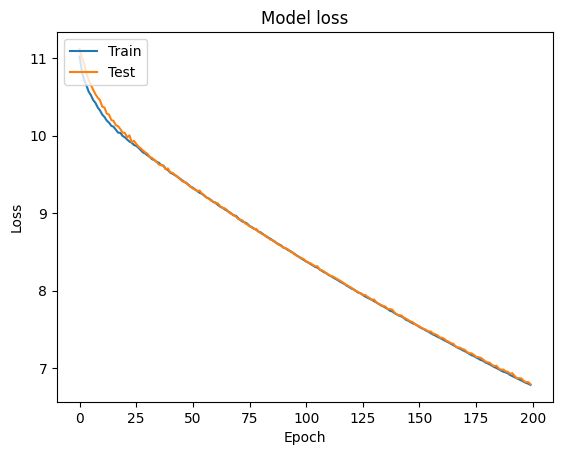

In [17]:
# prompt: plot the loss history of training and validation

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [18]:
#Evaluate the model

test_loss = model.evaluate(x_test_scaled, y_test_scaled)
print(f"Test Loss: {test_loss}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4431 - loss: 7.4941 - mae: 0.4874 - mse: 0.7651 - rmse: 0.8740
Test Loss: [7.451623916625977, 0.4146341383457184, 0.4792918264865875, 0.7225582003593445, 0.850034236907959]


In [19]:
# Make predictions on the test set
y_pred_scaled = model.predict(x_test_scaled)

# De-standardize the predictions using the same scaler as for y
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# De-standardize the actual values
y_test = scaler_y.inverse_transform(y_test_scaled).flatten()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 332ms/step


In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mae = mean_absolute_error(y_test_scaled, y_pred_scaled)
mse = mean_squared_error(y_test_scaled, y_pred_scaled)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')

Mean Absolute Error (MAE): 0.47929182411556553
Mean Squared Error (MSE): 0.7225581529195583


In [21]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'Mean Absolute Error (MAE) True Value: {mae}')
print(f'Mean Squared Error (MSE) True Value: {mse}')

Mean Absolute Error (MAE) True Value: 128.12498399400403
Mean Squared Error (MSE) True Value: 51627.75091079324


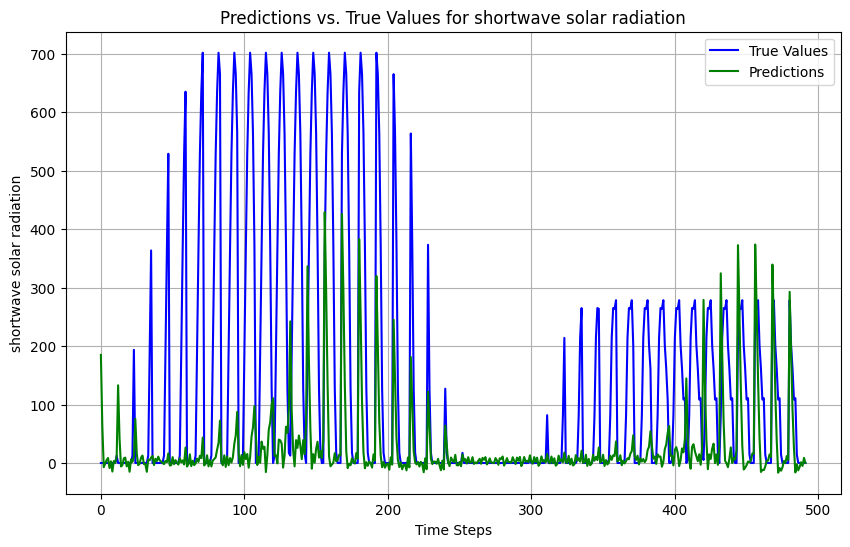

In [22]:
# prompt: plot the prediction vs true test

# Plot the predictions vs. true values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='True Values', color='blue')
plt.plot(y_pred, label='Predictions', color='green')
plt.title('Predictions vs. True Values for shortwave solar radiation')
plt.xlabel('Time Steps')
plt.ylabel('shortwave solar radiation')
plt.legend()
plt.grid(True)
plt.show()

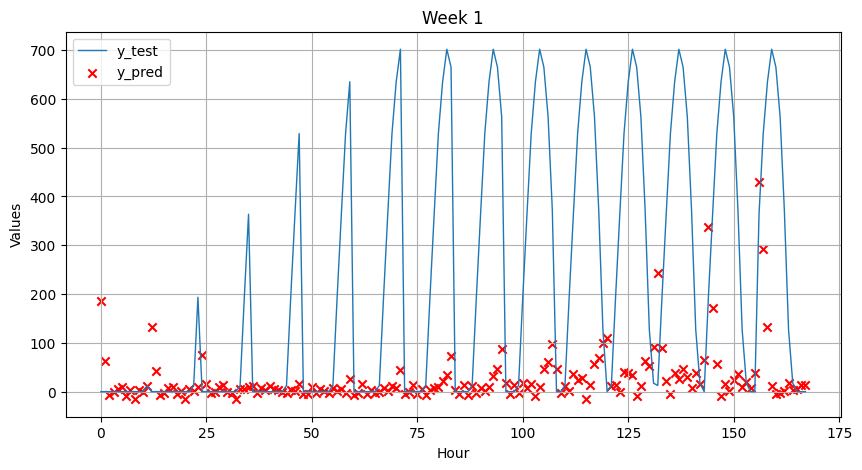

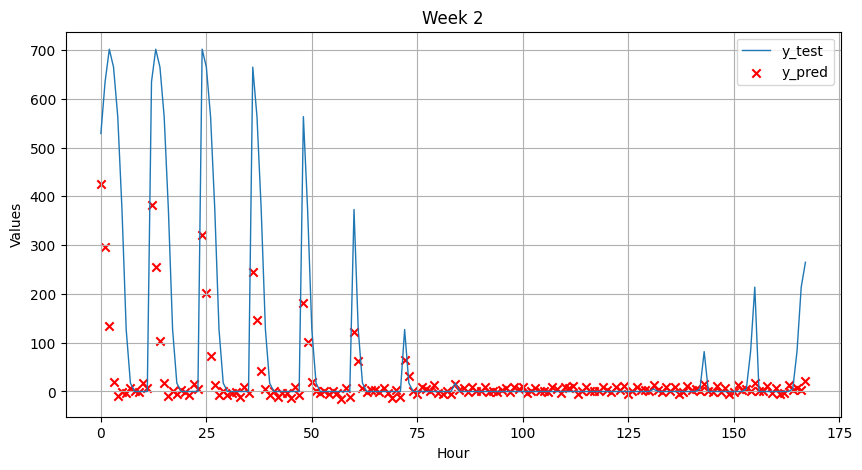

In [23]:
hours_per_week = 24 * 7

num_weeks = len(y_pred) // hours_per_week

for week in range(num_weeks):
    start_idx = week * hours_per_week
    end_idx = start_idx + hours_per_week
    plt.figure(figsize=(10, 5))  # Set ukuran figure
    plt.plot(y_test[start_idx:end_idx], label='y_test', linewidth=1)
    plt.scatter(range(hours_per_week), y_pred[start_idx:end_idx], color='red', marker='x', label='y_pred')
    plt.title(f'Week {week + 1}')
    plt.xlabel('Hour')
    plt.ylabel('Values')
    plt.legend()
    plt.grid(True)
    plt.show()